<a href="https://colab.research.google.com/github/ricecrackerLMC/iris---colab---project/blob/main/iris_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
#load the dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species"] = df["species"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

df.head()
df.shape

(150, 5)

In [ ]:
df = df.drop_duplicates()
df = df.dropna()

df.shape

(149, 5)

In [ ]:
#create a folder to save the graphs in:
import os
os.makedirs("graphs", exist_ok=True)

Graph 1:Sepal Length vs Sepal Width

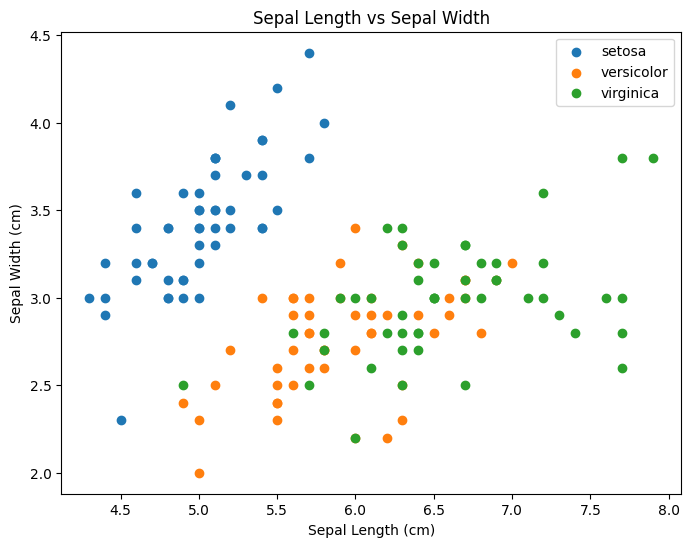

In [ ]:
plt.figure(figsize=(8, 6))
for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(subset["sepal length (cm)"], subset["sepal width (cm)"], label=species)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.legend()
plt.savefig("graphs/sepal_scatter.png", bbox_inches="tight")
plt.show()

Graph2: Petal Length vs Petal Width

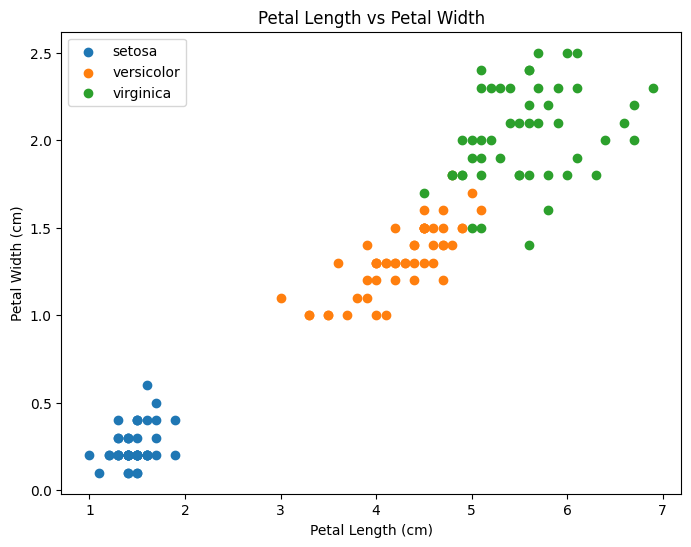

In [ ]:
plt.figure(figsize=(8, 6))
for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(subset["petal length (cm)"], subset["petal width (cm)"], label=species)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.savefig("graphs/petal_scatter.png", bbox_inches="tight")
plt.show()

We will train a logistic regression model to predict flower species.

In [ ]:
#prep the dataset
X = df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]]
y = df["species"]

#Split the Data 70% of the data is used to train the model, and 30% is used to test it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Train the model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
#make prediction
predictions = model.predict(X_test)

In [ ]:
#Evaluate the model
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 1.0

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

